In [1]:
suppressPackageStartupMessages({
    library(SummarizedExperiment)
    library(Matrix)
    library(dplyr)
    library(data.table)
    library(stringr)
    library(tidyr)
    library(ggplot2)
    library(reshape2)
    library(Signac)
    library(ggvenn)
    library(purrr)
    library(tibble)
    library(scales)
    "%ni%" <- Negate("%in%")   
    source("variant_calling.R")
    source("mtGene_color.R")
    source("Helper.R")
    source("quantifyMMB.R")
})

In [2]:
downsample.list <- list.files("mgatk_output/")
color_vec <- c("CTRL" = "#2780FF", "KI36" = "#960096", "KIA2" = "#000090")

In [3]:
cov.list <- lapply(downsample.list, function(x){
    mito.SE <- readRDS(paste0("mgatk_output/", x, "/final/mgatk.rds"))
    cov_per_pos_cell <- assays(mito.SE)[['coverage']]
})
names(cov.list) <- downsample.list

In [4]:
cov.df <- as.data.frame(cbind(pos = zoo::rollmean(1:16569, 5),
do.call(cbind,lapply(cov.list, function(cov){
    zoo::rollmean(rowMeans(cov), 5)
}))))

In [5]:
split_sample_info <- function(df) {
  df %>%
    mutate(
      sample      = str_extract(group, "^[^_]+"),                # prefix before "_"
      reads_in_M = as.numeric(str_extract(group, "(?<=_)\\d+")) # digits after "_" before "M"
    )}

In [6]:
cov.df.CTRL <- cov.df[,c("pos", grep("^CTRL", colnames(cov.df), value = TRUE))]
cov.df.KIA2 <- cov.df[,c("pos", grep("^KIA2", colnames(cov.df), value = TRUE))]
cov.df.KI36 <- cov.df[,c("pos", grep("^KI36", colnames(cov.df), value = TRUE))]

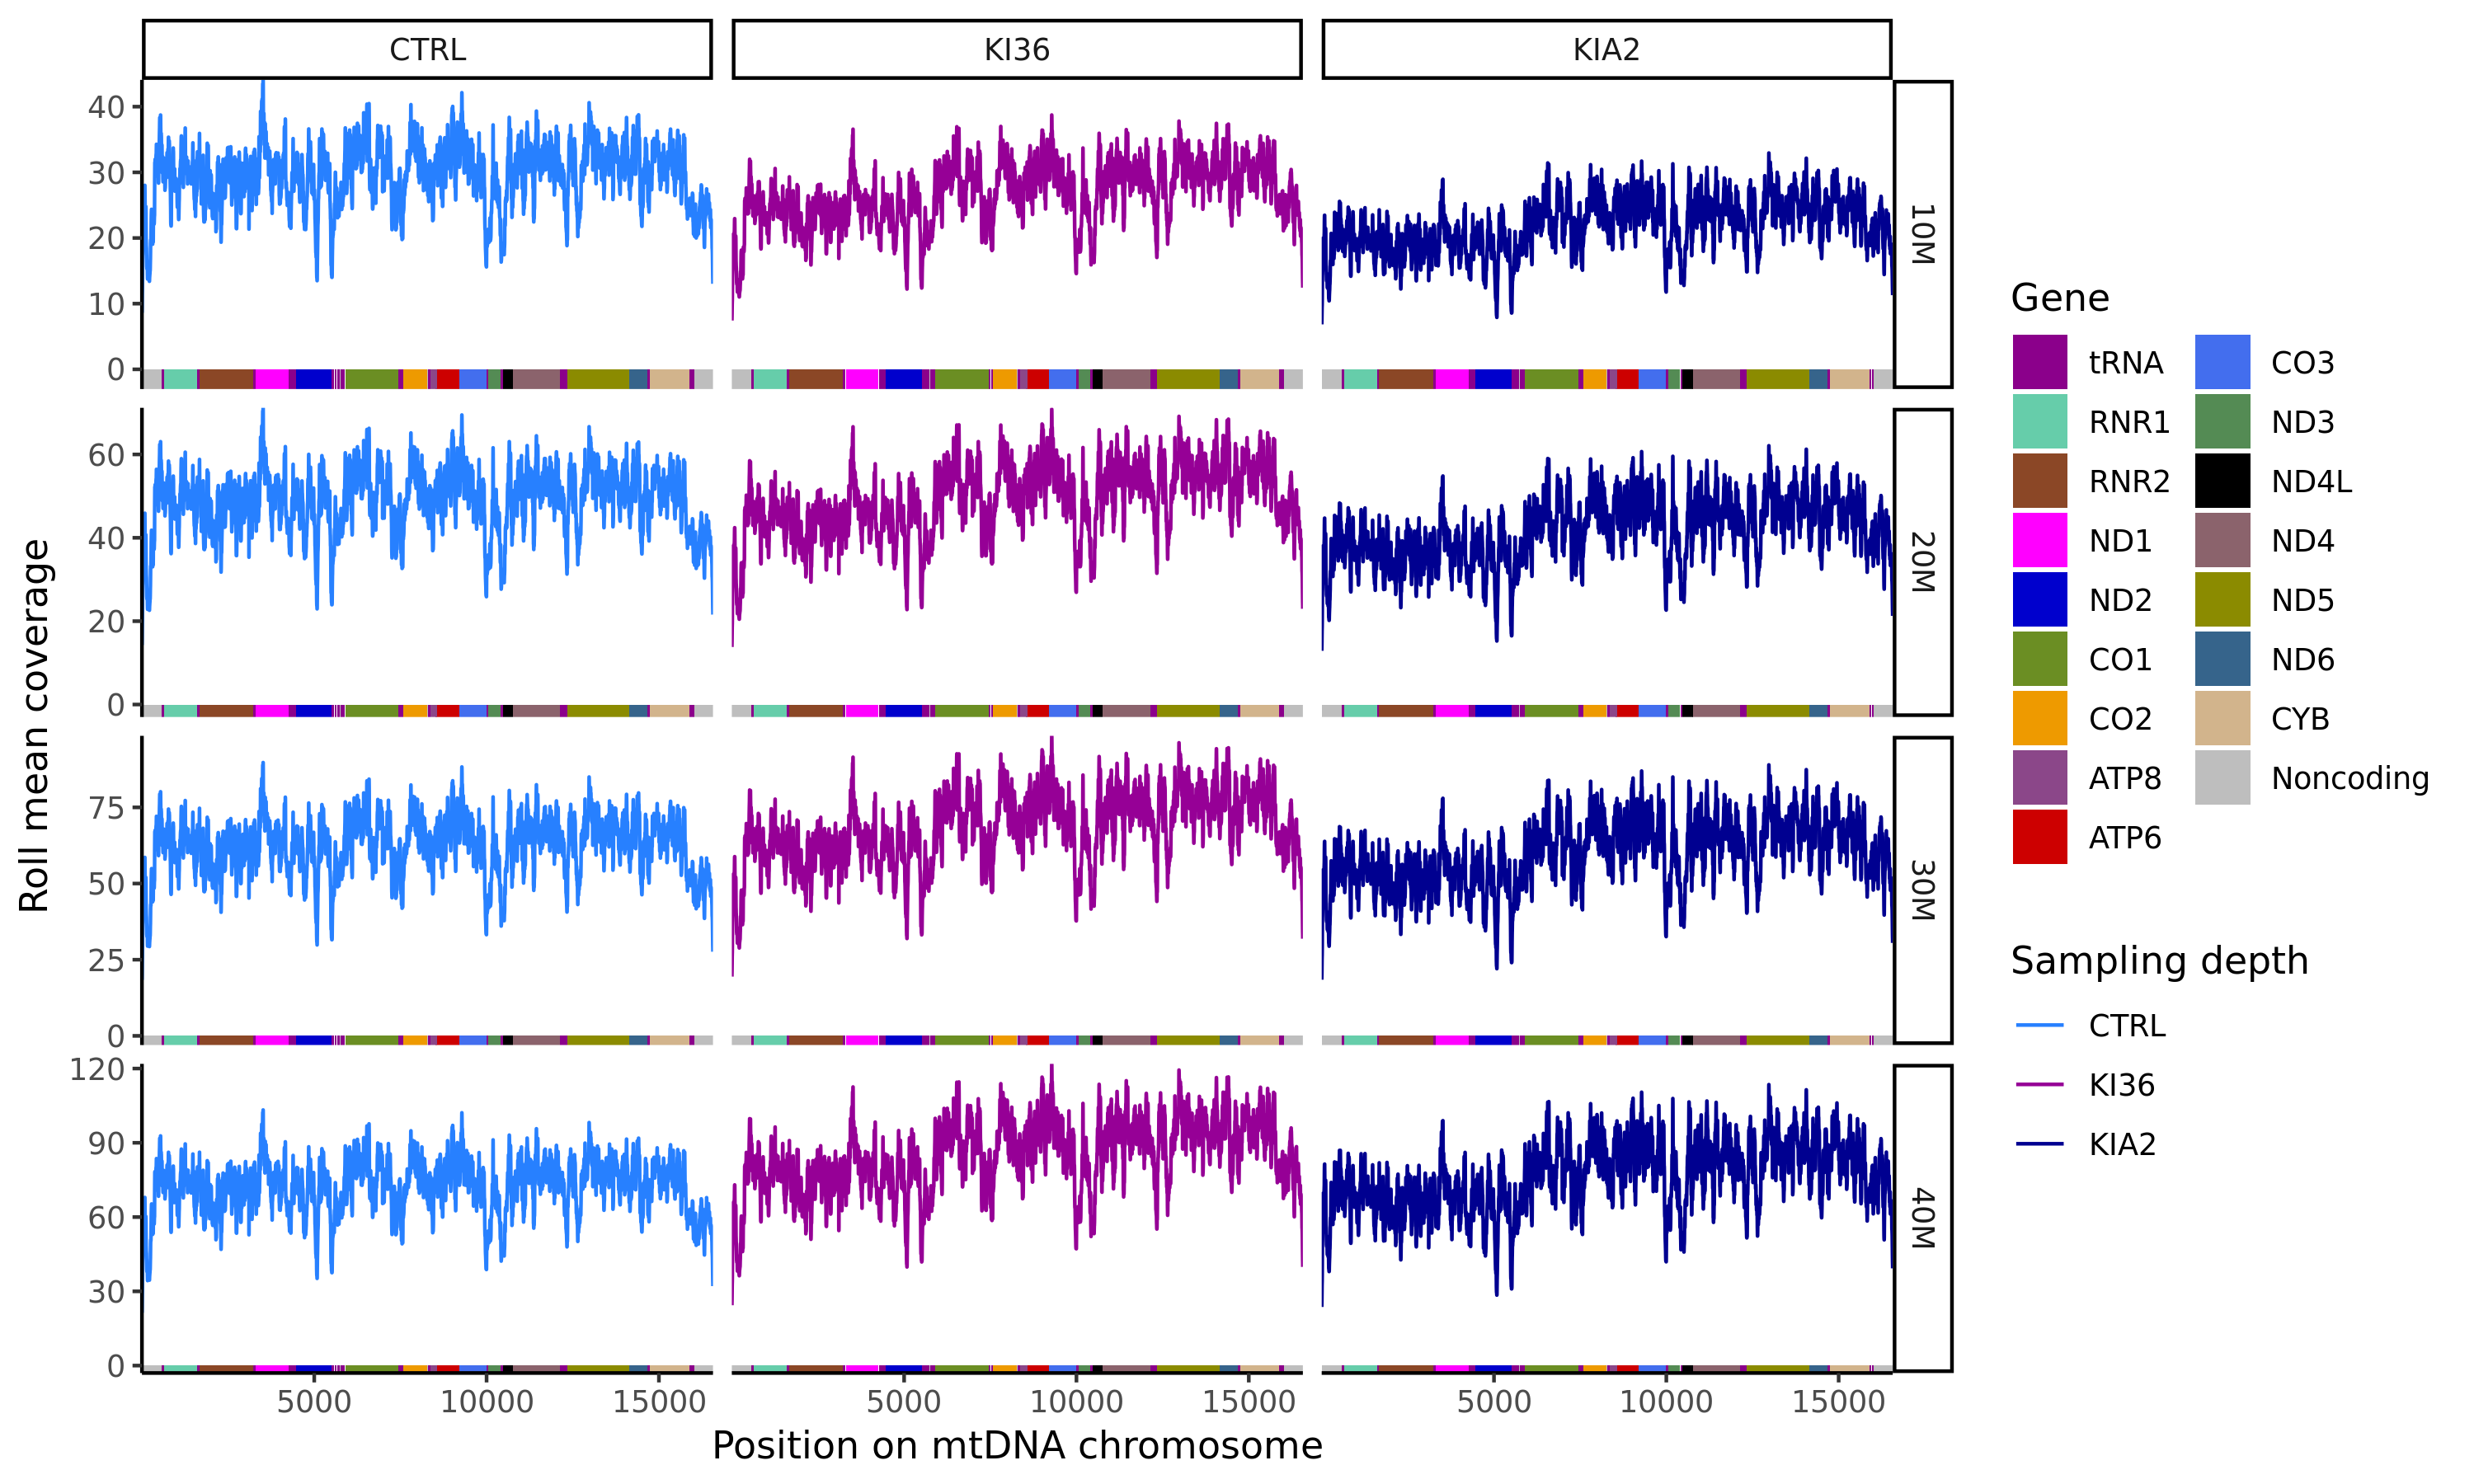

In [7]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)
make_cov_plot(cov.df)

In [8]:
mtDNA_depth <- do.call(rbind,lapply(1:length(cov.list), function(x){    
    data.frame(
        group = names(cov.list[x]),
        barcode = colnames(cov.list[[x]]),
        depth = as.vector(colMeans(cov.list[[x]]))
    )%>% split_sample_info()
    }) # end of lapply
                     ) %>% #end of do.call
group_by(reads_in_M, sample) %>% 
  mutate( # find outliner
    Q1 = quantile(depth, 0.25),
    Q3 = quantile(depth, 0.75),
    IQR = Q3 - Q1,
    lower = Q1 - 1.5 * IQR,
    upper = Q3 + 1.5 * IQR
  ) %>% 
  ungroup() %>%
  mutate(outlier = depth < 10 | depth > upper) %>% #| depth <= lower 
  filter(!outlier)

In [9]:
# compute median depth per reads_in_M, per sample
medians_df <- mtDNA_depth %>%
  group_by(reads_in_M, sample) %>%
  summarise(median_depth = median(depth, na.rm = TRUE), .groups = "drop")
medians_df

reads_in_M,sample,median_depth
<dbl>,<chr>,<dbl>
10,CTRL,24.15994
10,KI36,24.14041
10,KIA2,21.51355
20,CTRL,39.87700
20,KI36,43.02203
20,KIA2,39.18209
30,CTRL,51.20116
30,KI36,59.71112
30,KIA2,55.99831


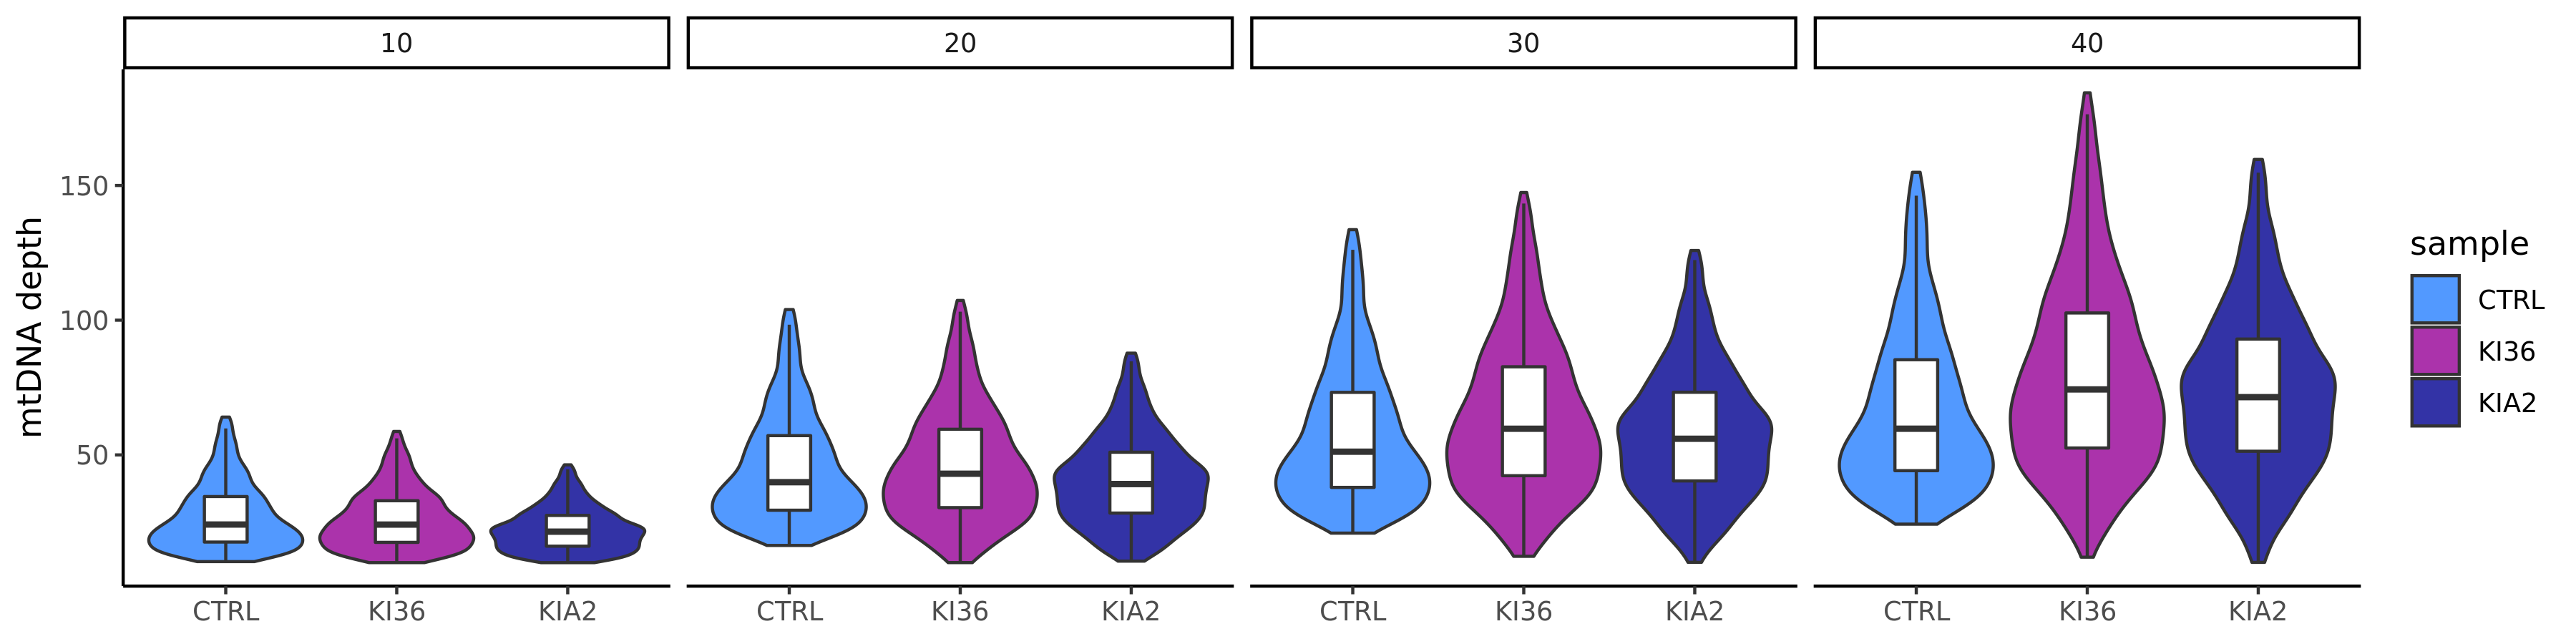

In [10]:
options(repr.plot.width = 12, repr.plot.height = 3, repr.plot.res = 300)

mtDNA_depth %>%
  filter(reads_in_M <= 40) %>%
  ggplot() +
  geom_violin(aes(x = sample, y = depth, group = sample, fill = sample), scale = "width", alpha = 0.8) +
  scale_fill_manual(values = color_vec) +
  geom_boxplot(aes(x = sample, y = depth, group = sample), width = 0.25, outlier.shape = NA) +
  # geom_smooth(data = medians_df, aes(y = median_depth, x = sample), 
  #            method = "lm", se = FALSE, color = "blue") +                         # regression line on medians
  # geom_point(data = medians_df, aes(x = sample, y = median_depth), color = "red", size = 1) +   # show medians
  facet_wrap(~reads_in_M, ncol=4) + theme_classic() +
  ylab("mtDNA depth") + xlab(NULL)

`geom_smooth()` using method = 'loess' and formula 'y ~ x'

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“span too small.   fewer data values than degrees of freedom.”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at 9.85”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 20.15”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 406.02”


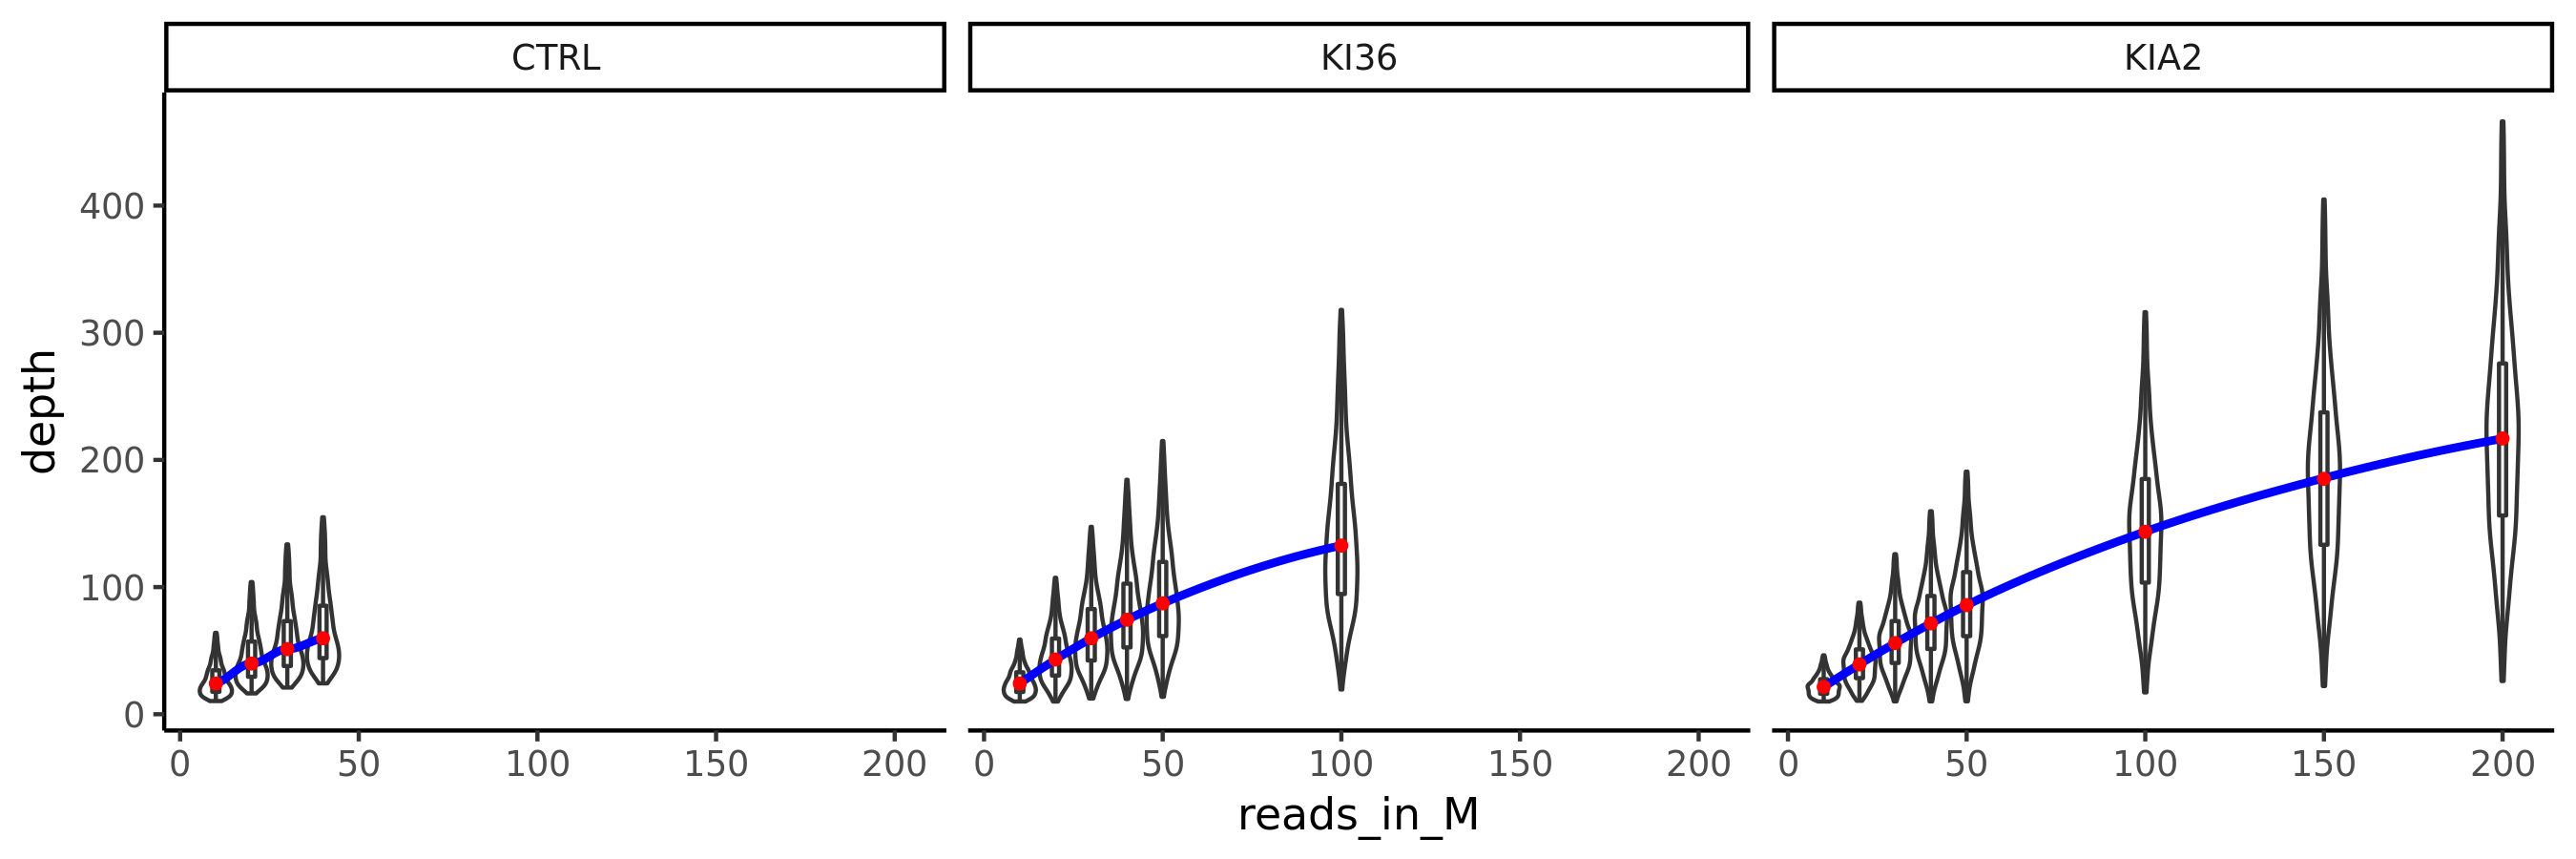

In [11]:
options(repr.plot.width = 9, repr.plot.height = 3, repr.plot.res = 300)

mtDNA_depth %>%
  filter(!outlier) %>%
  ggplot() +
  geom_violin(aes(x = reads_in_M, y = depth, group = reads_in_M), scale = "width") +
  geom_boxplot(aes(x = reads_in_M, y = depth, group = reads_in_M), width = 2, outlier.shape = NA) +
  geom_smooth(data = medians_df, aes(y = median_depth, x = reads_in_M), 
              se = FALSE, color = "blue") +                         # regression line on medians
  geom_point(data = medians_df, aes(x = reads_in_M, y = median_depth), color = "red", size = 1) +   # show medians
  facet_wrap(~sample)  + theme_classic()

In [12]:
mmat.list <- lapply(downsample.list, function(SampleID){
    readRDS(paste0("output/", SampleID,"_mmat.rds"))
})

In [13]:
names(mmat.list) <- downsample.list

In [14]:
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 300)

suppressWarnings(
lapply(1:length(mmat.list), function(x){
    mmat <- mmat.list[[x]]
    SampleID <- downsample.list[x]
    counts <- as.data.frame(rowData(mmat)) %>% subset(n_cells_conf_detected >= 1 & 
                                                      strand_correlation > 0.65 & vmr > 0.005) %>% nrow()
  plt <- VariantPlot(as.data.frame(rowData(mmat)), vmr.threshold = 0.005) + 
    labs(title = SampleID, subtitle = paste0("Number of somatic variants: ", counts)) + 
    scale_y_log10(limits = c(-5,1), n.breaks = 7) + scale_x_continuous(limits = c(-0.6,1), n.breaks = 4)
    ggsave(plot = plt, paste0("plot/22_VMR_",SampleID,".pdf"), width = 3, height = 3)
})
)

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.

Scale for 'y' is already present. Adding another scale for 'y', 

[[1]]
[1] "plot/22_VMR_CTRL_10M.pdf"

[[2]]
[1] "plot/22_VMR_CTRL_20M.pdf"

[[3]]
[1] "plot/22_VMR_CTRL_30M.pdf"

[[4]]
[1] "plot/22_VMR_CTRL_40M.pdf"

[[5]]
[1] "plot/22_VMR_KI36_100M.pdf"

[[6]]
[1] "plot/22_VMR_KI36_10M.pdf"

[[7]]
[1] "plot/22_VMR_KI36_20M.pdf"

[[8]]
[1] "plot/22_VMR_KI36_30M.pdf"

[[9]]
[1] "plot/22_VMR_KI36_40M.pdf"

[[10]]
[1] "plot/22_VMR_KI36_50M.pdf"

[[11]]
[1] "plot/22_VMR_KIA2_100M.pdf"

[[12]]
[1] "plot/22_VMR_KIA2_10M.pdf"

[[13]]
[1] "plot/22_VMR_KIA2_150M.pdf"

[[14]]
[1] "plot/22_VMR_KIA2_200M.pdf"

[[15]]
[1] "plot/22_VMR_KIA2_20M.pdf"

[[16]]
[1] "plot/22_VMR_KIA2_30M.pdf"

[[17]]
[1] "plot/22_VMR_KIA2_40M.pdf"

[[18]]
[1] "plot/22_VMR_KIA2_50M.pdf"

In [15]:
mmat.het.list <- lapply(mmat.list,function(mmat){
    var <- as.data.frame(rowData(mmat)) %>% 
           subset(n_cells_conf_detected >= 1 & 
                   strand_correlation > 0.65 & 
                   vmr > 0.005 &
                   position %ni% c(301, 302, 310, 316, 3107, 16182)) %>%
           pull(variant)  
    mmat <- mmat[var,]
    return(mmat)
})

In [16]:
mut = sapply(mmat.het.list,function(mmat){as.data.frame(rowData(mmat)) %>% nrow()}) 
mut = as.data.frame(mut) %>% tibble::rownames_to_column(var = "group") %>% 
    split_sample_info() %>% arrange(sample, reads_in_M) 
mut

group,mut,sample,reads_in_M
<chr>,<int>,<chr>,<dbl>
CTRL_10M,680,CTRL,10
CTRL_20M,897,CTRL,20
CTRL_30M,1104,CTRL,30
CTRL_40M,1210,CTRL,40
KI36_10M,1687,KI36,10
KI36_20M,3251,KI36,20
KI36_30M,4636,KI36,30
KI36_40M,5722,KI36,40
KI36_50M,6698,KI36,50


`geom_smooth()` using formula 'y ~ x'



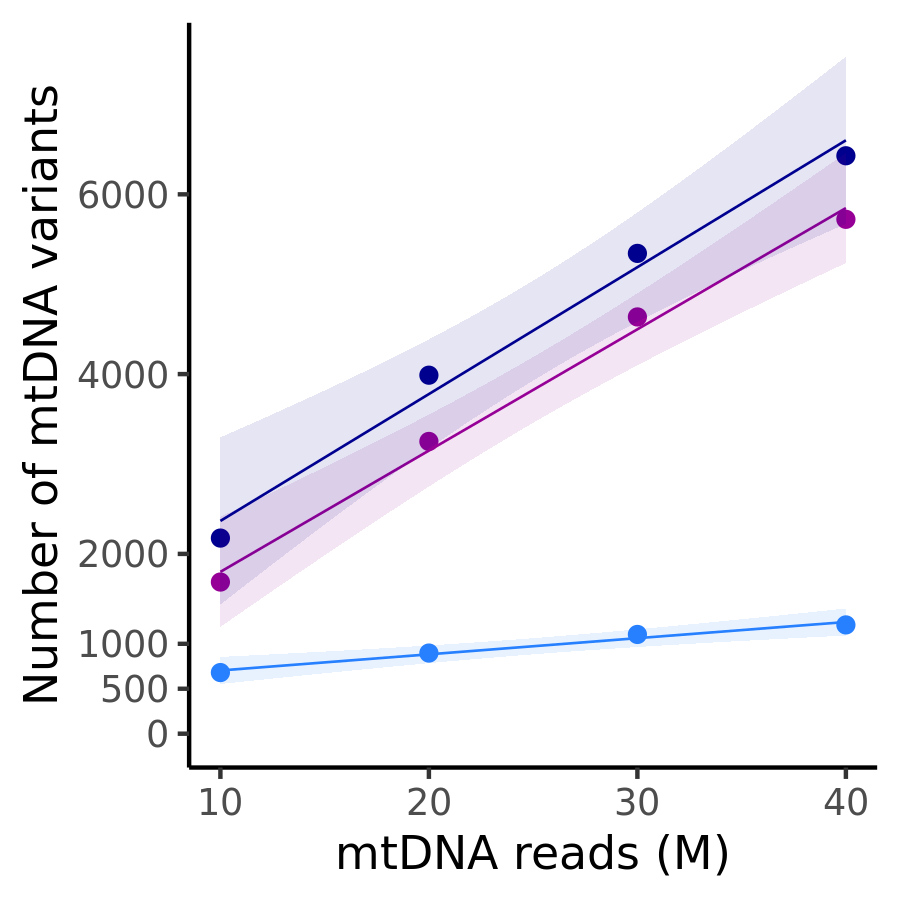

In [17]:
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 300)

(Fig7a <- mut %>% filter(reads_in_M < 50) %>% 
    ggplot(aes(x = reads_in_M, y = mut, col= sample, fill = sample)) +
    geom_point() + 
    geom_smooth(method = "lm", size =0.3, alpha = 0.1) +
    scale_x_continuous(limits = c(10, NA)) +
    scale_y_continuous(limits = c(0, NA), breaks = c(0, 500, 1000, 2000, 4000, 6000)) +
    scale_color_manual(values = color_vec) +
    scale_fill_manual(values = color_vec) +
    theme_classic() +
    theme(legend.position="none") +
    labs(x = "mtDNA reads (M)", y = "Number of mtDNA variants"))
    


In [18]:
ggsave(plot = Fig7a   , "plot/Ext_7a_count_low_depth.pdf", height = 3, width =3, dpi = 300)

`geom_smooth()` using formula 'y ~ x'



In [19]:
lm_stats <-  mut %>% 
  filter(reads_in_M < 50) %>%
   group_by(sample) %>%
  do({
    m <- lm(mut ~ reads_in_M, data = .)
    s <- summary(m)
    tibble(
      intercept      = coef(m)[1],
      slope          = coef(m)[2],
      r              = sign(coef(m)[2]) * sqrt(s$r.squared),
      r.squared      = s$r.squared,
      adj.r.squared  = s$adj.r.squared,
      p.value_slope  = coef(s)["reads_in_M", "Pr(>|t|)"]
    )
  }) %>%
  ungroup()
lm_stats
  

sample,intercept,slope,r,r.squared,adj.r.squared,p.value_slope
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CTRL,523.5,17.97,0.9893516,0.9788166,0.9682249,0.010648387
KI36,451.5,134.90,0.9968366,0.9936833,0.9905250,0.003163351
KIA2,955.5,141.14,0.9933632,0.9867705,0.9801557,0.006636796


In [20]:
Fig7b <- mut %>% filter(sample != "CTRL")%>% 
    ggplot(aes(x = reads_in_M, y = mut, col= sample, fill = sample)) +
    geom_point() + 
    # geom_abline(slope = 18.00, intercept = 523.0, linetype='dashed', color='grey') +
    geom_smooth(size =0.3, alpha = 0.2) + # method = 'loess' and formula 'y ~ x'
    scale_color_manual(values = color_vec) +
    scale_fill_manual(values = color_vec) +
    scale_y_continuous(limits = c(0, NA)) +
    # geom_point(aes(x = 100, y = 2323), color='grey') + 
    theme_classic() +
    theme(legend.position="none") +
    labs(x = "mtDNA reads (M)", y = "Number of mtDNA variants")

ggsave(plot = Fig7b   , "plot/Ext_7b_count_high_depth.pdf", height = 3, width =3, dpi = 300)
    

`geom_smooth()` using method = 'loess' and formula 'y ~ x'

Warning message in max(ids, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”


In [21]:
nCount_scMut <- do.call(rbind,lapply(1:length(mmat.het.list), CountscMut))

nCount_scMut <- nCount_scMut %>% select(-label) %>% 
    inner_join(mtDNA_depth %>% select(barcode, reads_in_M, depth, sample, outlier), by = c("barcode", "reads_in_M", "sample"))
head(nCount_scMut)




barcode,sample,reads_in_M,threshold,count,depth,outlier
<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<lgl>
AAACGAAAGTCTGCTA-1,CTRL,10,0,28,16.32718,FALSE
AAACGAAAGTCTGCTA-1,CTRL,10,5,26,16.32718,FALSE
AAACGAAAGTCTGCTA-1,CTRL,10,10,20,16.32718,FALSE
AAACGAAAGTCTGCTA-1,CTRL,10,15,8,16.32718,FALSE
AAACGAAAGTCTGCTA-1,CTRL,10,20,4,16.32718,FALSE
AAACGAAAGTCTGCTA-1,CTRL,10,25,3,16.32718,FALSE


In [22]:
medians_df_sc <- nCount_scMut %>% 
  group_by(reads_in_M, threshold, sample) %>%
  summarise(median_count = median(count, na.rm = TRUE), .groups = "drop")


`geom_smooth()` using formula 'y ~ x'

`geom_smooth()` using formula 'y ~ x'



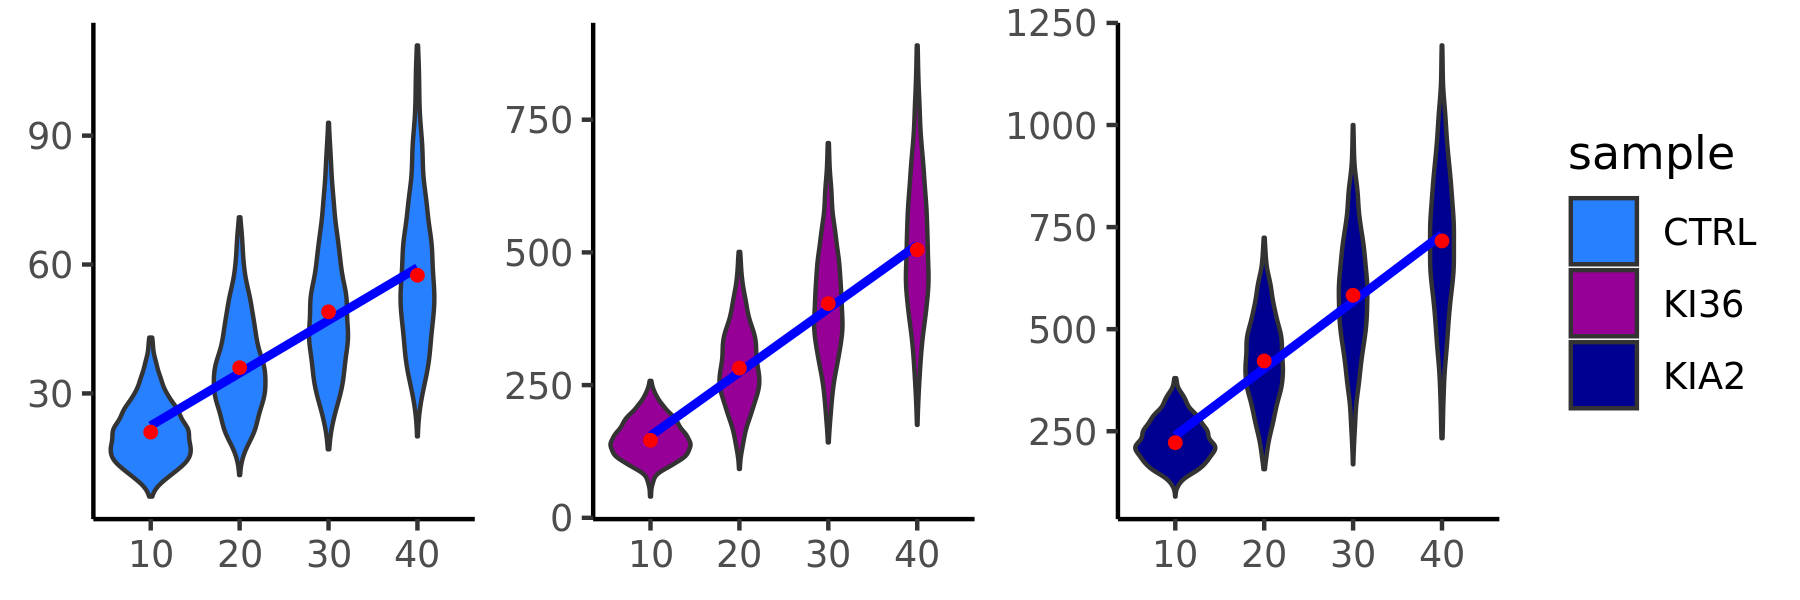

In [23]:
options(repr.plot.width = 6, repr.plot.height = 2, repr.plot.res = 300)
(nCount_Mut_low <-  nCount_scMut %>% 
    filter(threshold == 0) %>% 
    group_by(reads_in_M, sample) %>% 
    mutate( # find outliner
    Q1 = quantile(count, 0.25),
    Q3 = quantile(count, 0.75),
    IQR = Q3 - Q1,
    lower = Q1 - 1.5 * IQR,
    upper = Q3 + 1.5 * IQR
  ) %>% 
  ungroup() %>%
  mutate(outlier = count <= lower | count >= upper) %>% 
  filter(!outlier & reads_in_M <= 40)%>% 
    ggplot() +
    geom_violin(aes(x = reads_in_M, y = count, group = reads_in_M, fill = sample)) +
    facet_wrap(~sample, scale = "free") +
  geom_smooth(data = medians_df_sc %>% filter(threshold == 0 & reads_in_M <= 40), aes(y = median_count, x = reads_in_M), 
              method = "lm", se = FALSE, color = "blue") +                         # regression line on medians
  scale_fill_manual(values = color_vec) +
  geom_point(data = medians_df_sc %>% filter(threshold == 0 & reads_in_M <= 40), aes(x = reads_in_M, y = median_count), color = "red", size = 1) +   # show medians
  facet_wrap(~sample, scale = "free") + theme_classic() + 
    theme(
      strip.background = element_blank(),
      strip.text.x = element_blank()
    ) + xlab(NULL) + ylab(NULL))

ggsave(plot = nCount_Mut_low   , "plot/Ext_7c_nCount_scMut_low_depth.pdf", height = 2, width =6, dpi = 300)


In [24]:
medians_df_sc %>% 
  filter(reads_in_M < 50 & threshold ==0) %>%
   group_by(sample) %>%
  do({
    m <- lm(median_count ~ reads_in_M, data = .)
    s <- summary(m)
    tibble(
      intercept      = coef(m)[1],
      slope          = coef(m)[2],
      r              = sign(coef(m)[2]) * sqrt(s$r.squared),
      r.squared      = s$r.squared,
      adj.r.squared  = s$adj.r.squared,
      p.value_slope  = coef(s)["reads_in_M", "Pr(>|t|)"]
    )
  }) %>%
  ungroup()
  

sample,intercept,slope,r,r.squared,adj.r.squared,p.value_slope
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CTRL,10.25,1.225,0.9928309,0.9857131,0.9785697,0.007169142
KI36,34.50,11.985,0.9979244,0.9958530,0.9937796,0.002075631
KIA2,75.00,16.430,0.9958463,0.9917098,0.9875647,0.004153718


`geom_smooth()` using method = 'loess' and formula 'y ~ x'

Warning message in max(ids, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
`geom_smooth()` using method = 'loess' and formula 'y ~ x'

Warning message in max(ids, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”


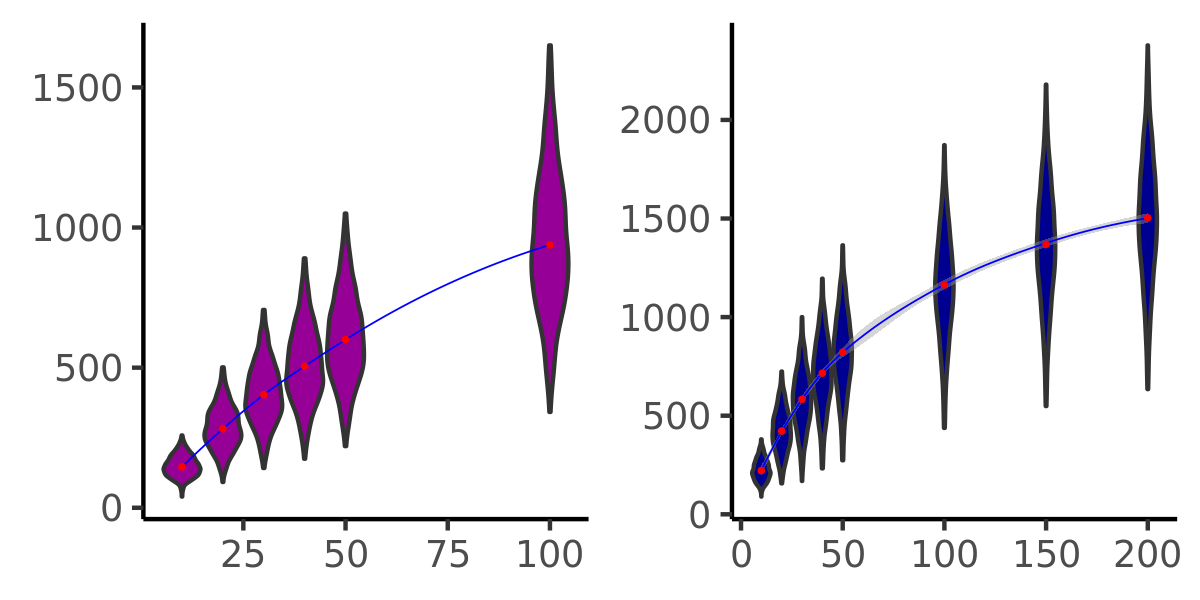

In [25]:
options(repr.plot.width = 4, repr.plot.height = 2, repr.plot.res = 300)
(nCount_Mut_high <-  nCount_scMut %>% 
    filter(threshold == 0) %>% 
    group_by(reads_in_M, sample) %>% 
    mutate( # find outliner
    Q1 = quantile(count, 0.25),
    Q3 = quantile(count, 0.75),
    IQR = Q3 - Q1,
    lower = Q1 - 1.5 * IQR,
    upper = Q3 + 1.5 * IQR
  ) %>% 
  ungroup() %>%
  mutate(outlier = count <= lower | count >= upper) %>% 
  filter(!outlier & sample != "CTRL")%>% 
    ggplot() +
    geom_violin(aes(x = reads_in_M, y = count, group = reads_in_M, fill = sample), scale = "width") +
    facet_wrap(~sample, scale = "free") +
  geom_smooth(data = medians_df_sc %>% filter(threshold == 0 & sample != "CTRL"), 
              aes(y = median_count, x = reads_in_M), 
              color = "blue", size = 0.2) + # regression line on medians
  geom_point(data = medians_df_sc %>% filter(threshold == 0 & sample != "CTRL"), 
             aes(x = reads_in_M, y = median_count), 
             color = "red", size = 0.2) +   # show medians
  scale_fill_manual(values = color_vec) +
  facet_wrap(~sample, scale = "free") + theme_classic() + 
    theme(
      strip.background = element_blank(),
      strip.text.x = element_blank()
    ) + xlab(NULL) + ylab(NULL) + Seurat::NoLegend())
ggsave(plot = nCount_Mut_high   , "plot/Ext_7d_nCount_scMut_high_depth.pdf", height = 2, width =4, dpi = 300)


In [26]:
var.list = sapply(mmat.het.list,function(mmat){
    as.data.frame(rowData(mmat)) %>% pull(variant)}) 

# make_venn_pdfs(var.list)

# get non-parental variants
result <- filter_variants_relative_to_CTRL(var.list)

mmat.list.filtered <- lapply(names(mmat.list), function(id){mmat.list[[id]][result[[id]],]})
names(mmat.list.filtered)<- names(mmat.list)

sapply(result, length)

CTRL_10M  CTRL_20M  CTRL_30M  CTRL_40M KI36_100M  KI36_10M  KI36_20M  KI36_30M 
      240       170       150       111      9104      1517      2905      4097 
 KI36_40M  KI36_50M KIA2_100M  KIA2_10M KIA2_150M KIA2_200M  KIA2_20M  KIA2_30M 
     5053      5974      8424      1829      9688     10444      3373      4523 
 KIA2_40M  KIA2_50M 
     5442      6228

In [27]:
scmtMMB_HEK <- do.call(rbind,lapply(1:18,function(idx){
  rbind(
    quantify_MMB(mmat.list.filtered[[idx]], cov.list[[idx]],names(mmat.list.filtered[idx])),
    quantify_MMB_psedobulk(mmat.list.filtered[[idx]], cov.list[[idx]],names(mmat.list.filtered[idx])))
})) %>% 
    mutate(
        reads_in_M = as.numeric(str_extract(sample, "(?<=_)\\d+")), # digits after "_" before "M"
        sample     = str_extract(sample, "^[^_]+")                # prefix before "_"
    ) 


In [28]:
scmtMMB_HEK <- scmtMMB_HEK %>% inner_join(mtDNA_depth %>% 
            select(barcode, reads_in_M, depth, sample), by = c("barcode", "reads_in_M", "sample"))

In [29]:
HEK_metadata <- read.csv("1_HEK_metadata.csv",header = TRUE, row.names = 1)

In [30]:
scmtMMB_HEK <- scmtMMB_HEK %>% 
    group_by(reads_in_M, sample, symbol) %>% 
  mutate( # find outliner
    scwMSS_Q1 = quantile(MSS_weighted, 0.25, na.rm = T),
    scwMSS_Q3 = quantile(MSS_weighted, 0.75, na.rm = T),
    scwMSS_IQR = scwMSS_Q3 - scwMSS_Q1,
    scwMSS_lower = scwMSS_Q1 - 1.5 * scwMSS_IQR,
    scwMSS_upper = scwMSS_Q3 + 1.5 * scwMSS_IQR,
    scMPM_Q1 = quantile(mutation_per_MB, 0.25, na.rm = T),
    scMPM_Q3 = quantile(mutation_per_MB, 0.75, na.rm = T),
    scMPM_IQR = scMPM_Q3 - scMPM_Q1,
    scMPM_lower = scMPM_Q1 - 1.5 * scMPM_IQR,
    scMPM_upper = scMPM_Q3 + 1.5 * scMPM_IQR
  ) %>% 
  ungroup() %>%
  mutate(MSS_outlier = MSS_weighted <= scwMSS_lower   | MSS_weighted >= scwMSS_upper,
         MPM_outlier = mutation_per_MB <= scMPM_lower | mutation_per_MB >= scMPM_upper,
         outlier = MPM_outlier | MSS_outlier) %>% filter(!outlier)

In [31]:
options(repr.plot.width = 2, repr.plot.height = 2, repr.plot.res = 300)
p_scwMSS <- scmtMMB_HEK %>% filter(sample == "KIA2" & symbol == "Total" & depth >= 10) %>% 
  ggplot(aes(x = reads_in_M, y = MSS_weighted + 0.01, group = reads_in_M, fill = sample)) +
  geom_violin(scale = "width") + facet_wrap(~sample, scales =  "free_y") +
  theme_classic() + xlab(NULL) +
  scale_fill_manual(values = c("KI36" = "#960096", "KIA2" = "#000090"))+
  scale_y_continuous(trans = log2_trans(), 
                     breaks = trans_breaks("log2", function(x) 2^x), 
                     labels = trans_format("log2", math_format(2^.x)),
                     limits = c(0.1, NA)) + 
  labs(y = bquote(paste(log[2], "(scwMSS + 0.01)"))) + 
    theme(
      strip.background = element_blank(),
      strip.text.x = element_blank()
    ) + Seurat::NoLegend()

p_scmtMPM <- scmtMMB_HEK %>% filter(sample == "KIA2" & symbol == "Total" & depth >= 10) %>% 
  ggplot(aes(x = reads_in_M, y = mutation_per_MB + 1, group = reads_in_M, fill = sample)) +
  geom_violin(scale = "width") + facet_wrap(~sample, scales = "free_y")+
  theme_classic() + xlab(NULL) + 
  scale_fill_manual(values = c("KI36" = "#960096", "KIA2" = "#000090"))+
  scale_y_log10(breaks = trans_breaks("log10", function(x) 10^x), 
                labels = trans_format("log10", math_format(10^.x)),
                limits = c(1, NA)) + 
  labs(y = bquote(paste(log[10], "(scmtMPM + 1)"))) + 
    theme(
      strip.background = element_blank(),
      strip.text.x = element_blank()
    ) + Seurat::NoLegend()

ggsave(plot = p_scwMSS   , "plot/Ext_7h_scwMSS_deptDS.pdf", height = 3, width =3, dpi = 300)
ggsave(plot = p_scmtMPM  , "plot/Ext_7h_scmtMPM_deptDS.pdf", height = 3, width =3, dpi = 300)

In [32]:
write.csv(scmtMMB_HEK, "output/scmtMMB_HEK_DSA.csv", quote = FALSE, row.names = TRUE)


In [33]:
library(purrr)

depths <- c("200", "150", "100", "50", "30", "10")

kia2_df <- map_dfr(
  depths,
  ~ as.data.frame(rowData(mmat.het.list[[paste0("KIA2_", .x, "M")]])) %>%
      select(variant, mean) %>%
      mutate(depth = .x)
)

In [34]:
dim(mmat.het.list$KIA2_200M)
dim(mmat.het.list$KIA2_50M)

[1] 11563  1894

[1] 7251 1894

In [35]:
rownames(kia2_df) <- seq_len(nrow(kia2_df))

In [36]:
kia2_wide <- kia2_df %>% pivot_wider(names_from = "depth", values_from = "mean") %>% filter(complete.cases(.))

In [37]:
kia2_long <- kia2_wide %>%
  pivot_longer(
    cols = -variant,
    names_to = "depth",
    values_to = "VAF"
  ) %>%
  mutate(
    depth = factor(depth, levels = c("10", "30", "50", "100", "150", "200"))
  )

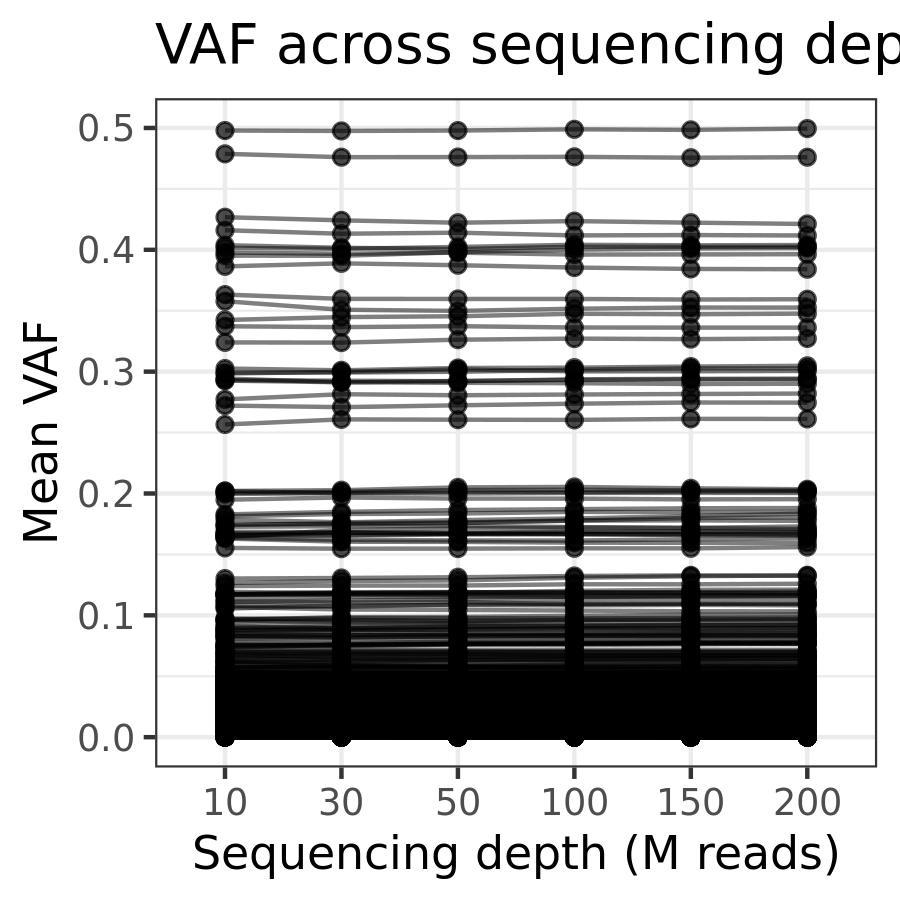

In [38]:
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 300)
ggplot(kia2_long, aes(x = depth, y = VAF, group = variant)) +
  geom_line(alpha = 0.5) +
  geom_point(alpha = 0.7) +
  theme_bw() +
  labs(
    x = "Sequencing depth (M reads)",
    y = "Mean VAF",
    title = "VAF across sequencing depths for all variants"
  ) 

In [39]:
kia2_prop <- kia2_long %>%
  group_by(depth) %>%
  mutate(
    total_VAF = sum(VAF),
    prop = VAF / total_VAF
  ) %>%
  ungroup()

mito_colors <- MetBrewer::met.brewer("Signac", length(unique(kia2_prop$variant)))
names(mito_colors) <- c(unique(kia2_prop$variant))

set.seed(123)
kia2_prop <- kia2_prop %>%
  mutate(
    variant = factor(variant),
    variant = factor(variant, levels = sample(levels(variant)))  # shuffle levels
  )

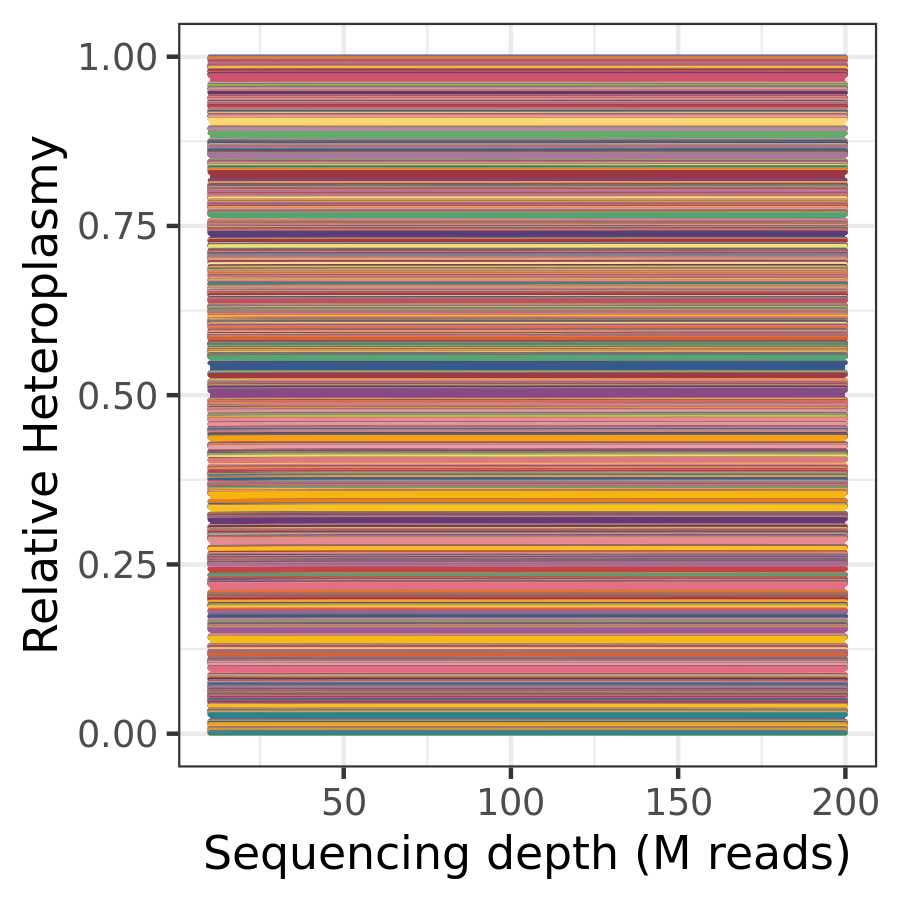

In [40]:
# Option 1: let ggplot use its default palette on shuffled levels
(VAF_stream_depth <- ggplot(kia2_prop, aes(x = as.numeric(as.character(depth)), y = prop, fill = variant, color =variant)) +
  geom_area(position = "stack") +
  #scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_color_manual(values=mito_colors) +
  scale_fill_manual(values=mito_colors) +
  theme_bw() +
  labs(
    x = "Sequencing depth (M reads)",
    y = "Relative Heteroplasmy",
    # title = "Variant contribution to total VAF across sequencing depths",
    fill = "Variant"
  ) +
  Seurat::NoLegend())

ggsave(plot = VAF_stream_depth   , "plot/Ext_7e_VAF_stream_depth.pdf", height = 3, width =3, dpi = 300)


Coordinate system already present. Adding new coordinate system, which will replace the existing one.



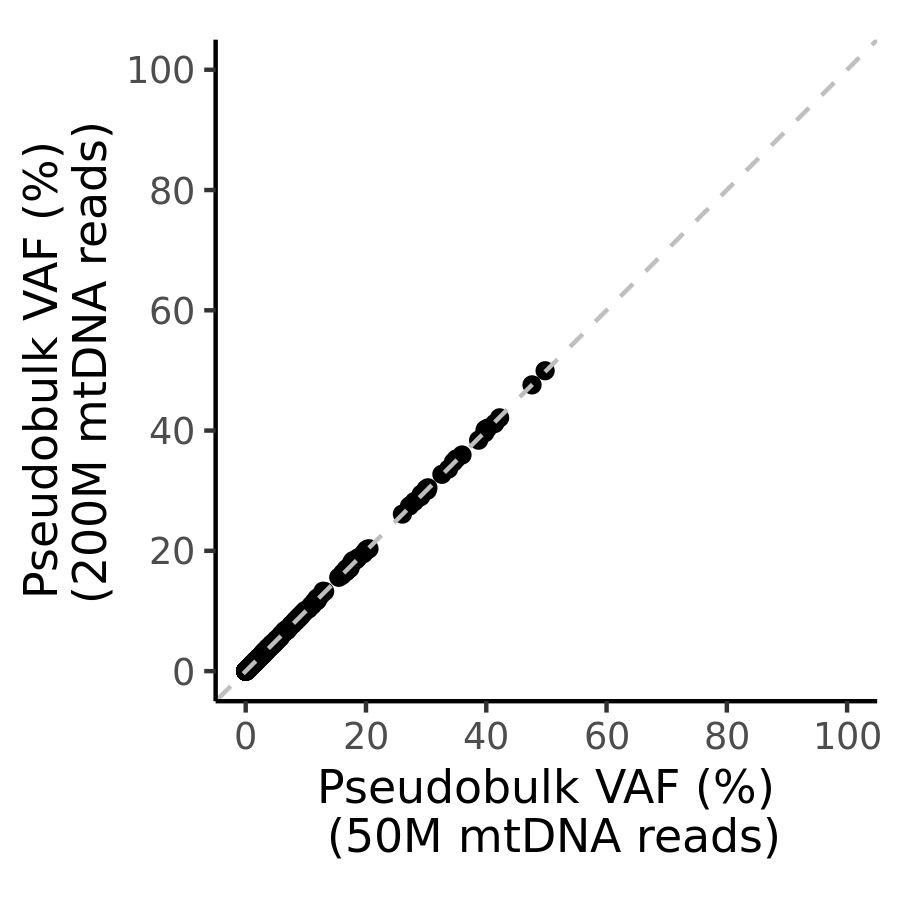

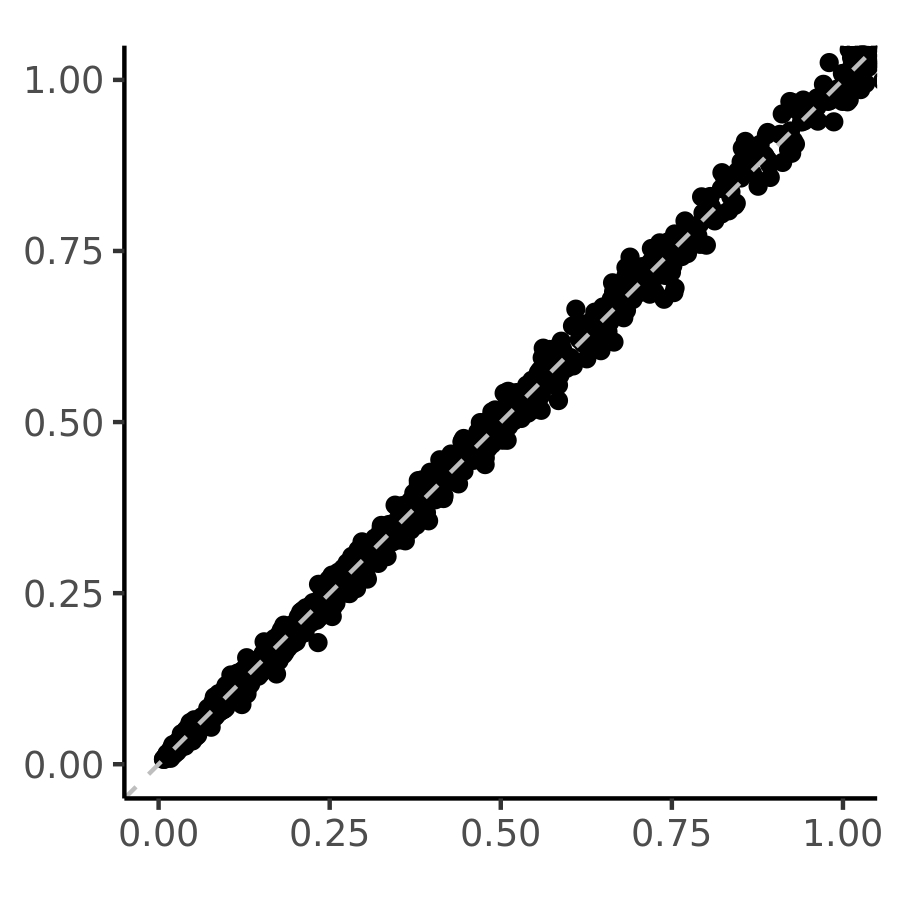

In [41]:
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 300)

p_50v200_base <- kia2_wide %>% 
    ggplot(aes(x = `50`* 100, y = `200`* 100)) +
    geom_point() +
    theme_classic() +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey") +
    coord_equal(xlim = c(0,100), ylim = c(0,100), expand = TRUE) + theme_classic()


(p_50v200_full <- p_50v200_base +
    scale_x_continuous(breaks = seq(0, 100, by = 20)) +
    scale_y_continuous(breaks = seq(0, 100, by = 20)) +
    xlab("Pseudobulk VAF (%)\n (50M mtDNA reads)") +
    ylab("Pseudobulk VAF (%)\n (200M mtDNA reads)"))

(p_50v200_insets <- p_50v200_base + 
    coord_equal(xlim = c(0,1), ylim = c(0,1), expand = TRUE) +
    scale_x_continuous(breaks = seq(0, 1, by = 0.25)) +
    scale_y_continuous(breaks = seq(0, 1, by = 0.25)) +
    xlab(NULL) +
    ylab(NULL))



In [42]:
ggsave(plot = p_50v200_full   , "plot/Ext_7f_VAF_50v200_full.pdf", height = 3, width =3, dpi = 300)
ggsave(plot = p_50v200_insets , "plot/Ext_7f_VAF_50v200_zoom.pdf", height = 3, width =3, dpi = 300)

In [43]:
all_pos = data.frame(
    position = 1:16569,
    change = rep("line", 16569),
    cell = rep("line", 16569),
    value = 0
)
var <- intersect(rownames(mmat.het.list$KIA2_50M), rownames(mmat.het.list$KIA2_200M))

In [44]:
length(var)

[1] 7101

In [45]:
length(colnames(mmat.het.list$KIA2_50M))

[1] 1894

In [46]:
library(tibble)
df_parsed_200 <- as.data.frame(assay(mmat.het.list$KIA2_200M[var, ]))%>% 
rownames_to_column("variant") %>% 
  extract(
    col   = variant,
    into  = c("position", "change"),
    #  -> group 1: all digits (position)
    #  -> group 2: base change like C>A, G>A...
    regex = "^([0-9]+)([ACGT]>[ACGT])$",
    convert = TRUE
  )

df_parsed_50 <-  as.data.frame(assay(mmat.het.list$KIA2_50M[var, ]))%>% 
rownames_to_column("variant") %>% 
  extract(
    col   = variant,
    into  = c("position", "change"),
    #  -> group 1: all digits (position)
    #  -> group 2: base change like C>A, G>A...
    regex = "^([0-9]+)([ACGT]>[ACGT])$",
    convert = TRUE
  )

In [47]:
# 1. Pivot to long format: one row per (position, cell)
df_long_50 <- df_parsed_50 %>%
  arrange(position) %>%                             # make sure x is ordered
  pivot_longer(
    cols = -c(position, change),                    # all barcode columns
    names_to = "cell",
    values_to = "value"
  )

# 1. Pivot to long format: one row per (position, cell)
df_long_200 <- df_parsed_200 %>%
  arrange(position) %>%                             # make sure x is ordered
  pivot_longer(
    cols = -c(position, change),                    # all barcode columns
    names_to = "cell",
    values_to = "value"
  )

In [48]:
df_long_50  <- rbind(all_pos, df_long_50)
df_long_200 <- rbind(all_pos, df_long_200)

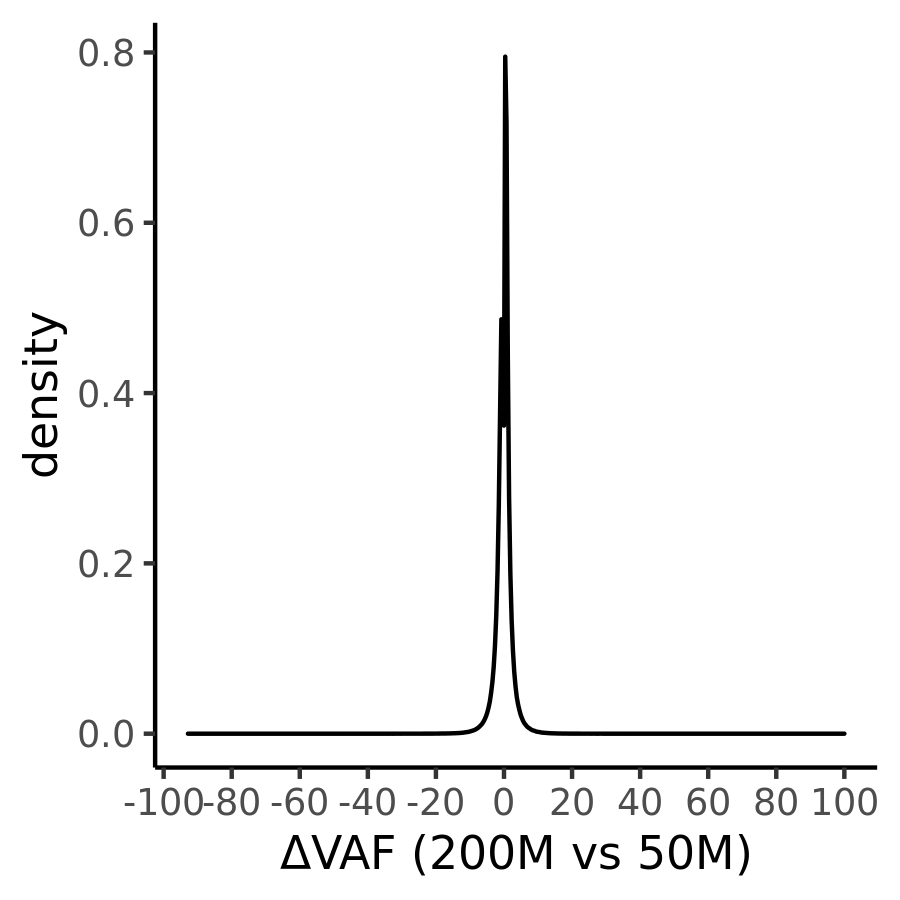

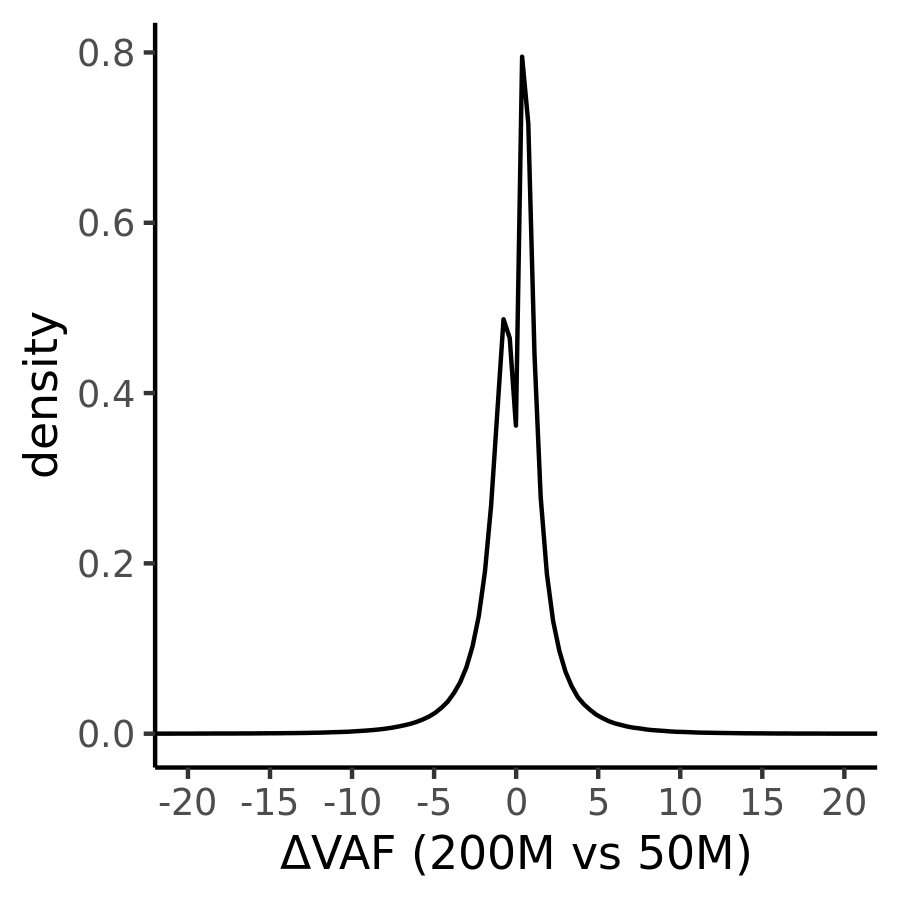

In [49]:
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 300)

base_df <- left_join(df_long_50, df_long_200,
                     by = c("position", "change", "cell"),
                     suffix = c("_50", "_200")) %>% 
  filter(!(value_50 == 0 & value_200 == 0)) %>% 
  mutate(delta = value_200 - value_50)

p_base_density <- base_df %>% 
  ggplot(aes(x = delta * 100)) +
  geom_density() +
  theme_classic() +
  xlab("ΔVAF (200M vs 50M)")

## 1) Full view
p_full_density <- p_base_density +
  scale_x_continuous(breaks = seq(-100, 100, by = 20))

## 2) Zoomed view, *same density*, just zoomed
p_zoom_density <- p_base_density +
  scale_x_continuous(breaks = seq(-20, 20, by = 5)) +
  coord_cartesian(xlim = c(-20, 20))

p_full_density
p_zoom_density



In [50]:
suppressWarnings(
    ggsave(plot = p_zoom_density, "plot/Ext_7g_deltaVAF.pdf", height = 3, width =3, dpi = 300)
)